In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
# Helper functions

def print_section(title):
    print("=" * 80)
    print(title)
    print("=" * 80)

def save_current_plot(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

def evaluate_classification_model(model_name, y_true, y_pred, y_prob):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    if y_prob is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_prob)
        results["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        results["roc_auc"] = np.nan
        results["pr_auc"] = np.nan

    return results

def plot_conf_matrix(y_true, y_pred, title, filename=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Rejected", "Approved"],
        yticklabels=["Rejected", "Approved"]
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    if filename:
        save_current_plot(filename)
    else:
        plt.show()


def get_feature_names_from_preprocessor(preprocessor):
    # Get transformed feature names 
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder":
            continue

        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
        else:
            last_step = transformer

        if hasattr(last_step, "get_feature_names_out"):
            try:
                names = last_step.get_feature_names_out(cols)
            except TypeError:
                names = last_step.get_feature_names_out()
            feature_names.extend(names)
        else:
            feature_names.extend(cols)

    return list(feature_names)


def find_best_threshold(y_true, y_prob, metric="f1"):
    # Test multiple thresholds and return a results table
    rows = []
    thresholds = np.arange(0.10, 0.91, 0.05)

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        row = {
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "accuracy": accuracy_score(y_true, y_pred),
        }
        rows.append(row)

    results = pd.DataFrame(rows)
    results = results.sort_values(by=metric, ascending=False).reset_index(drop=True)
    return results


def cross_validate_model(model, X, y, scoring, cv_splits=5):
    # Run stratified cross-validation and return summary metrics
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring, n_jobs=-1, return_train_score=False)

    summary = {}
    for key, values in cv_results.items():
        if key.startswith("test_"):
            metric_name = key.replace("test_", "")
            summary[f"cv_{metric_name}_mean"] = np.mean(values)
            summary[f"cv_{metric_name}_std"] = np.std(values)

    return pd.DataFrame([summary])

In [3]:
# Load data
print_section("LOAD DATA")
df = pd.read_csv("loan_data.csv")
print(f"Dataset shape: {df.shape}")
print(df.head())

LOAD DATA
Dataset shape: (45000, 14)
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49       

In [4]:
# Initial Data Inspection
print_section("INITIAL DATA INSPECTION")
print("\nColumn types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
print(df.describe(include="all").T)

INITIAL DATA INSPECTION

Column types:
person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

Missing values:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_incom

In [5]:
# Basic Data Cleaning

print_section("DATA CLEANING")

# Standardize column names
df.columns = df.columns.str.strip().str.lower()
TARGET_COL = "loan_status"

# Clean whitespace in text columns
for col in df.select_dtypes(include="object").columns:
    df.loc[:, col] = df[col].astype(str).str.strip()

# Remove unrealistic values
df = df[df["person_age"] <= 100].copy()
df.loc[:, "person_emp_exp"] = df["person_emp_exp"].clip(upper=70)

# Clean and encode binary field
# Handle both string (Yes/No) and already numeric (0/1) cases
if "previous_loan_defaults_on_file" in df.columns:
    if df["previous_loan_defaults_on_file"].dtype == "object":
        df.loc[:, "previous_loan_defaults_on_file"] = (
            df["previous_loan_defaults_on_file"]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({"yes": 1, "no": 0})
        )
    
    df["previous_loan_defaults_on_file"] = df["previous_loan_defaults_on_file"].astype(int)

print("Final shape after cleaning:", df.shape)
print("Target distribution after cleaning:")
print(df[TARGET_COL].value_counts(normalize=True))

DATA CLEANING
Final shape after cleaning: (44993, 14)
Target distribution after cleaning:
loan_status
0    0.777743
1    0.222257
Name: proportion, dtype: float64


C:\Users\taylo\AppData\Local\Temp\ipykernel_34636\1985193930.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0})


EDA

Target distribution:
loan_status
0    34993
1    10000
Name: count, dtype: int64
loan_status
0    0.777743
1    0.222257
Name: proportion, dtype: float64


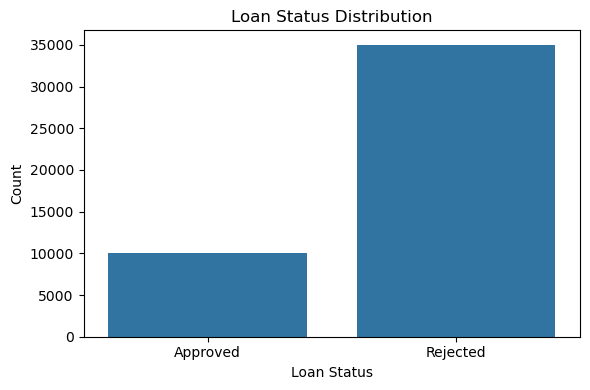

In [6]:
# Exploratory Data Analysis (EDA)

print_section("EDA")

OUTPUT_DIR = Path("project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Target distribution
print("\nTarget distribution:")
print(df[TARGET_COL].value_counts(dropna=False))
print(df[TARGET_COL].value_counts(normalize=True, dropna=False))

label_map = {0: "Rejected", 1: "Approved"}

plt.figure(figsize=(6, 4))
sns.countplot(x=df[TARGET_COL].map(label_map))
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
save_current_plot("target_distribution.png")

Numeric columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent']


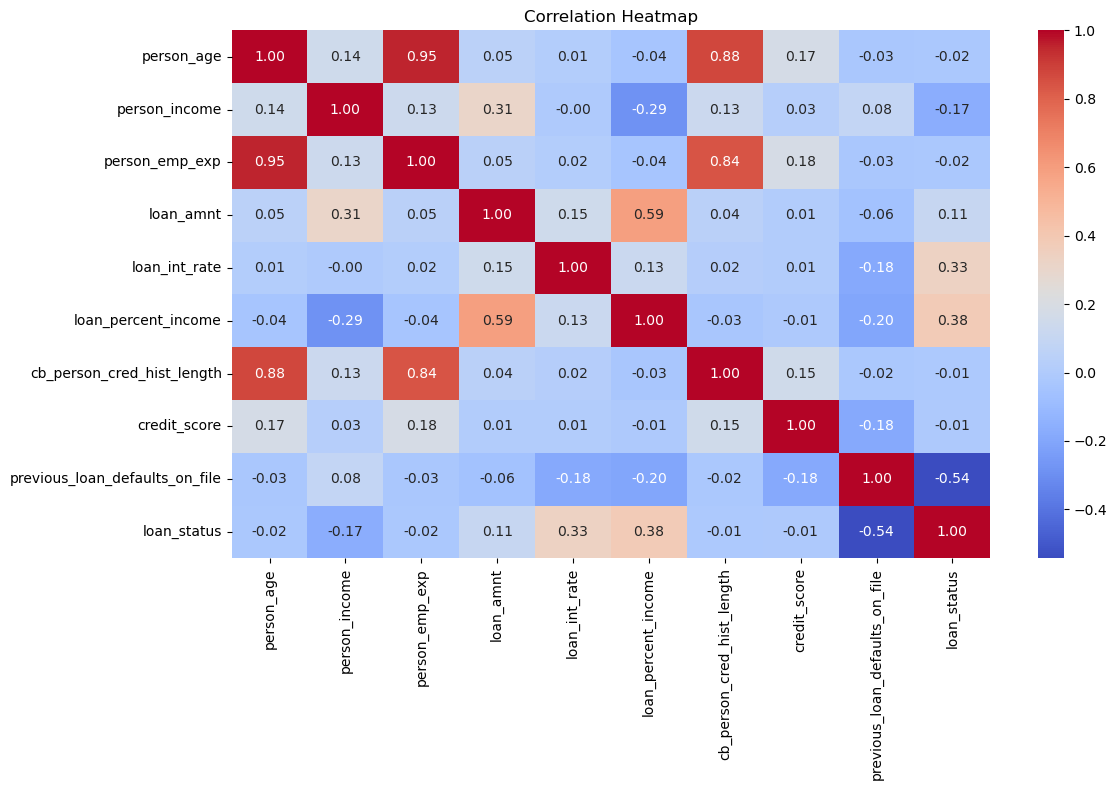

Top categories for person_gender:
person_gender
male      24836
female    20157
Name: count, dtype: int64
Top categories for person_education:
person_education
Bachelor       13396
Associate      12026
High School    11970
Master          6980
Doctorate        621
Name: count, dtype: int64
Top categories for person_home_ownership:
person_home_ownership
RENT        23440
MORTGAGE    18485
OWN          2951
OTHER         117
Name: count, dtype: int64
Top categories for loan_intent:
loan_intent
EDUCATION            9151
MEDICAL              8548
VENTURE              7815
PERSONAL             7551
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64


In [7]:
# Numeric and categorical summaries
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

if numeric_cols:
    plt.figure(figsize=(12, 8))
    corr = df[numeric_cols + [TARGET_COL]].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    save_current_plot("correlation_heatmap.png")

# Print categorical summaries
for col in categorical_cols:
    print(f"Top categories for {col}:")
    print(df[col].value_counts(dropna=False).head(10))

Approval rates for person_home_ownership:
loan_status           Rejected Approved
person_home_ownership                  
OTHER                    66.7%    33.3%
RENT                     67.6%    32.4%
MORTGAGE                 88.4%    11.6%
OWN                      92.5%     7.5%


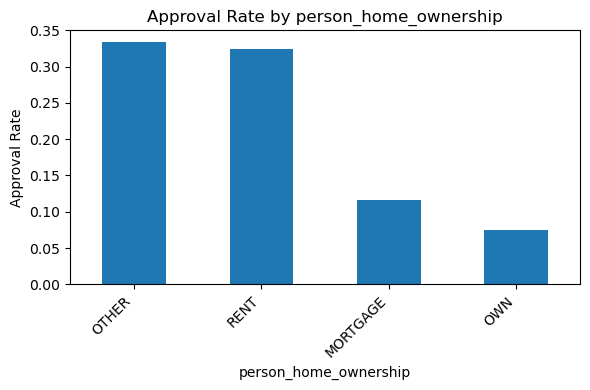

Approval rates for previous_loan_defaults_on_file:
loan_status                    Rejected Approved
previous_loan_defaults_on_file                  
0                                 54.8%    45.2%
1                                100.0%     0.0%


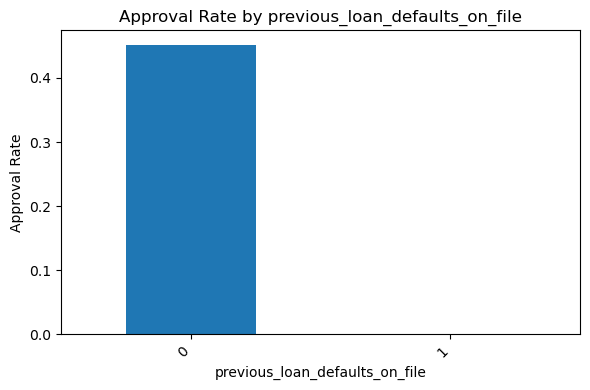

Approval rates for person_education:
loan_status      Rejected Approved
person_education                  
Doctorate           77.1%    22.9%
Bachelor            77.5%    22.5%
High School         77.7%    22.3%
Associate           78.0%    22.0%
Master              78.2%    21.8%


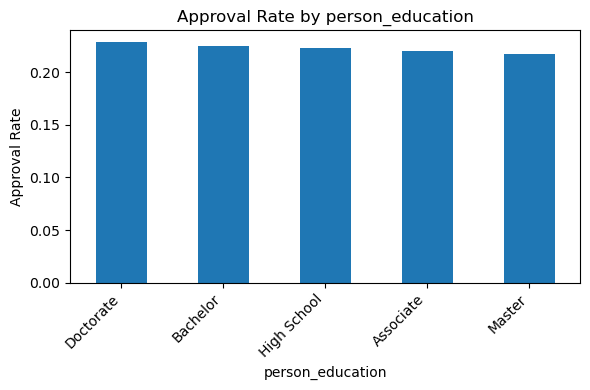

Approval rates for loan_intent:
loan_status       Rejected Approved
loan_intent                        
DEBTCONSOLIDATION    69.7%    30.3%
MEDICAL              72.2%    27.8%
HOMEIMPROVEMENT      73.7%    26.3%
PERSONAL             79.9%    20.1%
EDUCATION            83.0%    17.0%
VENTURE              85.6%    14.4%


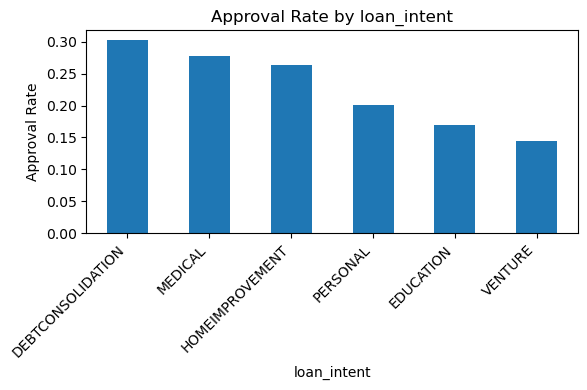

In [8]:
# Approval rate by key categorical features
candidate_cols = [
    "person_home_ownership",
    "previous_loan_defaults_on_file",
    "person_education",
    "loan_intent",
]

for col in candidate_cols:
    if col in df.columns:
        rate_table = pd.crosstab(df[col], df[TARGET_COL], normalize="index")

        # rename columns
        rate_table = rate_table.rename(columns={0: "Rejected", 1: "Approved"})

        # sort by approval rate
        rate_table = rate_table.sort_values(by="Approved", ascending=False)

        print(f"Approval rates for {col}:")
        print((rate_table * 100).round(1).astype(str) + "%")

        rate_table.to_csv(OUTPUT_DIR / f"approval_table_{col}.csv")

        plt.figure(figsize=(6, 4))
        rate_table["Approved"].plot(kind="bar")
        plt.title(f"Approval Rate by {col}")
        plt.ylabel("Approval Rate")
        plt.xticks(rotation=45, ha="right")
        save_current_plot(f"approval_rate_{col}.png")

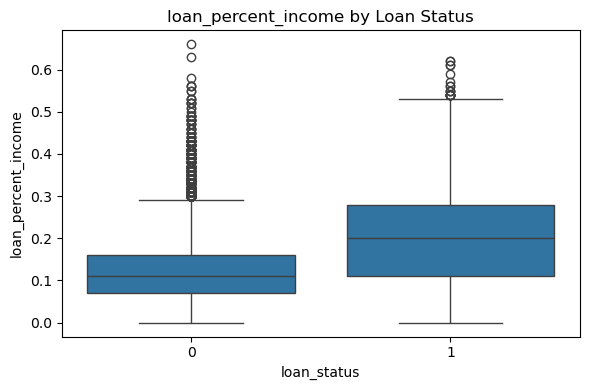

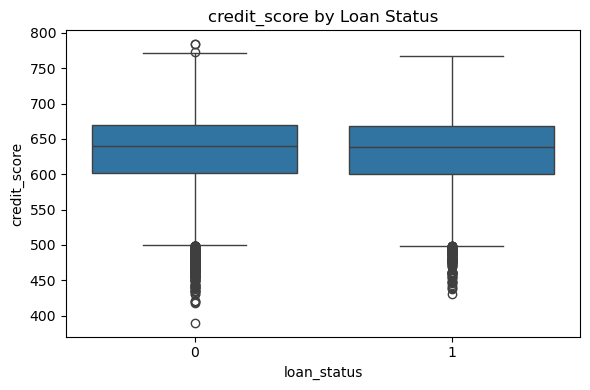

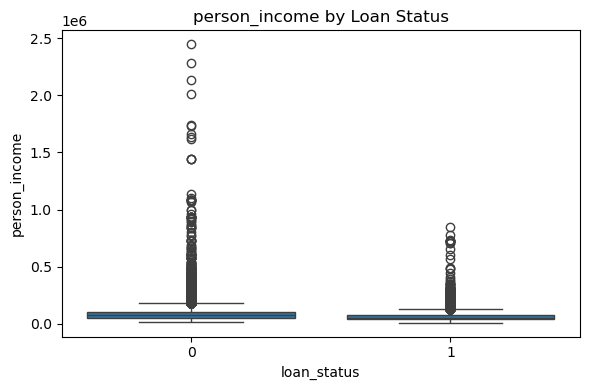

In [9]:
# Numeric features vs target
focused_numeric_plots = [
    "loan_percent_income",
    "credit_score",
    "person_income"
]

for col in focused_numeric_plots:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x=TARGET_COL, y=col)
        plt.title(f"{col} by Loan Status")
        save_current_plot(f"numeric_vs_target_{col}.png")

In [10]:
# Train / Test Split

print_section("TRAIN / TEST SPLIT")

RANDOM_STATE = 42
TEST_SIZE = 0.30

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

TRAIN / TEST SPLIT
X_train shape: (31495, 13)
X_test shape: (13498, 13)
y_train distribution:
loan_status
0    0.777742
1    0.222258
Name: proportion, dtype: float64
y_test distribution:
loan_status
0    0.777745
1    0.222255
Name: proportion, dtype: float64


In [11]:
# Preprocessing

print_section("PREPROCESSING")

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
numeric_transformer_unscaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor_log = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_unscaled, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

PREPROCESSING
Numeric features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Categorical features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent']


MODEL 1: LOGISTIC REGRESSION
Classification report:

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     10498
           1       0.62      0.91      0.74      3000

    accuracy                           0.85     13498
   macro avg       0.79      0.87      0.82     13498
weighted avg       0.89      0.85      0.86     13498

                 model  accuracy  precision    recall        f1   roc_auc  \
0  Logistic Regression  0.854423   0.616896  0.910333  0.735425  0.951998   

     pr_auc  
0  0.848288  


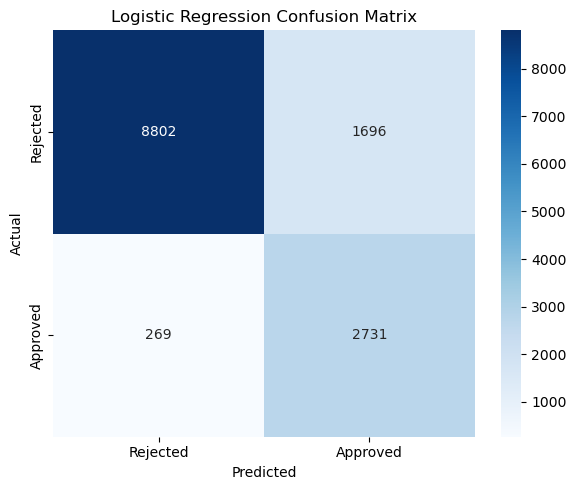

In [12]:
# Baseline Model: Logistic Regression

print_section("MODEL 1: LOGISTIC REGRESSION")

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_log),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

log_reg_pipeline.fit(X_train, y_train)
log_pred = log_reg_pipeline.predict(X_test)
log_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Classification report:\n")
print(classification_report(y_test, log_pred, zero_division=0))

log_results = evaluate_classification_model("Logistic Regression", y_test, log_pred, log_prob)
print(pd.DataFrame([log_results]))

plot_conf_matrix(y_test, log_pred, "Logistic Regression Confusion Matrix", "conf_matrix_logistic.png")

MODEL 2: RANDOM FOREST
Classification report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10498
           1       0.90      0.75      0.82      3000

    accuracy                           0.93     13498
   macro avg       0.92      0.86      0.89     13498
weighted avg       0.92      0.93      0.92     13498

           model  accuracy  precision  recall        f1   roc_auc    pr_auc
0  Random Forest  0.925841   0.903512   0.746  0.817236  0.973801  0.927675


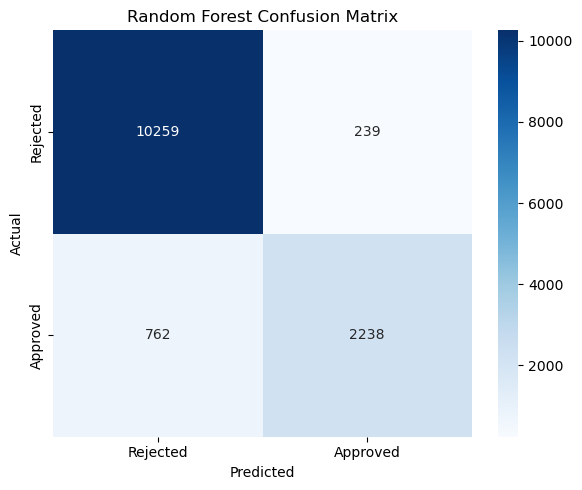

In [13]:
# Random Forest
print_section("MODEL 2: RANDOM FOREST")

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Classification report:\n")
print(classification_report(y_test, rf_pred, zero_division=0))

rf_results = evaluate_classification_model("Random Forest", y_test, rf_pred, rf_prob)
print(pd.DataFrame([rf_results]))

plot_conf_matrix(y_test, rf_pred, "Random Forest Confusion Matrix", "conf_matrix_random_forest.png")


MODEL 3: GRADIENT BOOSTING
Classification report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10498
           1       0.88      0.76      0.82      3000

    accuracy                           0.93     13498
   macro avg       0.91      0.87      0.89     13498
weighted avg       0.92      0.93      0.92     13498

               model  accuracy  precision    recall        f1   roc_auc  \
0  Gradient Boosting    0.9251   0.883533  0.763667  0.819238  0.971293   

     pr_auc  
0  0.922366  


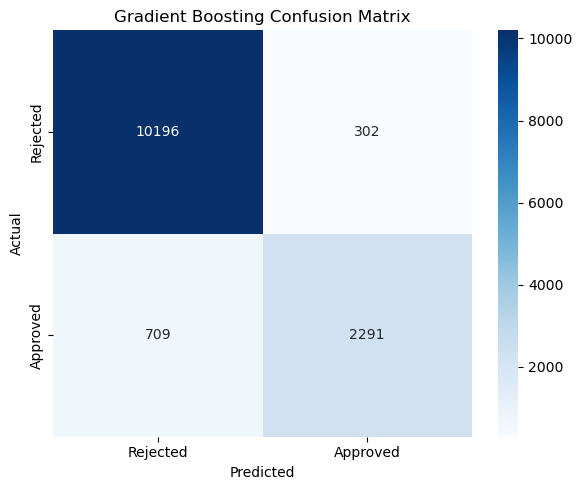

In [14]:
# Gradient Boosting

print_section("MODEL 3: GRADIENT BOOSTING")

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            GradientBoostingClassifier(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)
gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]

print("Classification report:\n")
print(classification_report(y_test, gb_pred, zero_division=0))

gb_results = evaluate_classification_model("Gradient Boosting", y_test, gb_pred, gb_prob)
print(pd.DataFrame([gb_results]))

plot_conf_matrix(y_test, gb_pred, "Gradient Boosting Confusion Matrix", "conf_matrix_gradient_boosting.png")

MODEL COMPARISON
                 model  precision  recall      f1  roc_auc  pr_auc
0    Gradient Boosting     0.8835  0.7637  0.8192   0.9713  0.9224
1        Random Forest     0.9035  0.7460  0.8172   0.9738  0.9277
2  Logistic Regression     0.6169  0.9103  0.7354   0.9520  0.8483


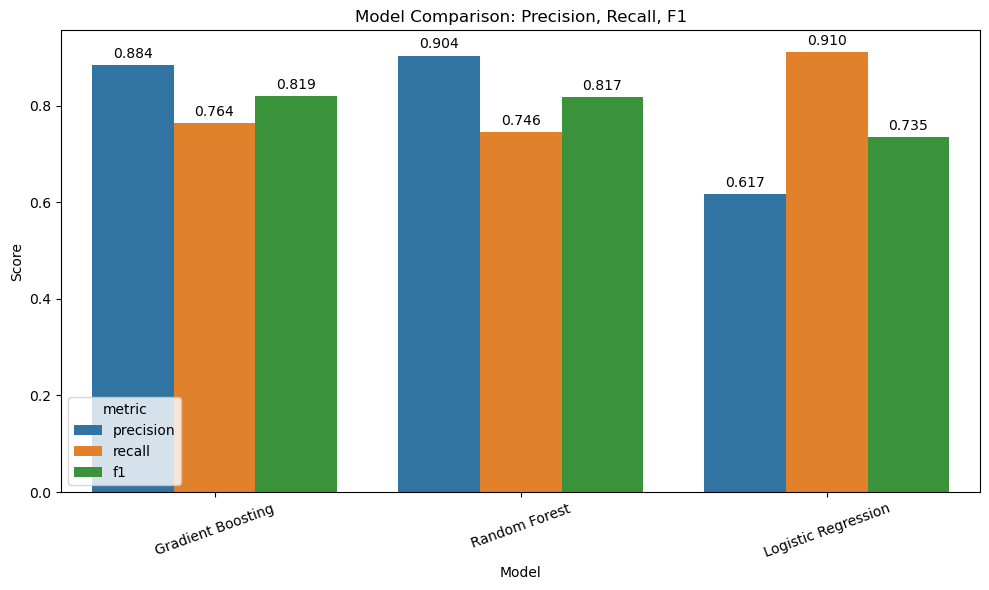

In [15]:
# Model Comparison
print_section("MODEL COMPARISON")

all_results = [log_results, rf_results, gb_results]

results_df = pd.DataFrame(all_results).sort_values(by="f1", ascending=False).reset_index(drop=True)
print(results_df[["model", "precision", "recall", "f1", "roc_auc", "pr_auc"]].round(4))
results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

# Reshape for plotting
plot_df = results_df[["model", "precision", "recall", "f1"]].melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=plot_df, x="model", y="score", hue="metric")

plt.title("Model Comparison: Precision, Recall, F1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

ax.legend(title="metric", loc="lower left")

save_current_plot("model_comparison_bar.png")
plt.show()

In [16]:
# Cross-Validation

print_section("CROSS-VALIDATION")

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv_log = cross_validate_model(log_reg_pipeline, X, y, scoring)
cv_log.insert(0, "model", "Logistic Regression")

cv_rf = cross_validate_model(rf_pipeline, X, y, scoring)
cv_rf.insert(0, "model", "Random Forest")

cv_gb = cross_validate_model(gb_pipeline, X, y, scoring)
cv_gb.insert(0, "model", "Gradient Boosting")

cv_results_df = pd.concat([cv_log, cv_rf, cv_gb], ignore_index=True)
print(cv_results_df)
cv_results_df.to_csv(OUTPUT_DIR / "cross_validation_summary.csv", index=False)

CROSS-VALIDATION
                 model  cv_accuracy_mean  cv_accuracy_std  cv_precision_mean  \
0  Logistic Regression          0.856978         0.005442           0.620479   
1        Random Forest          0.927789         0.003114           0.904651   
2    Gradient Boosting          0.924966         0.002622           0.880282   

   cv_precision_std  cv_recall_mean  cv_recall_std  cv_f1_mean  cv_f1_std  \
0          0.010225          0.9190       0.003194    0.740749   0.007497   
1          0.010077          0.7547       0.007560    0.822878   0.007547   
2          0.007837          0.7667       0.005680    0.819566   0.006138   

   cv_roc_auc_mean  cv_roc_auc_std  cv_average_precision_mean  \
0         0.953976        0.002082                   0.854067   
1         0.974789        0.001664                   0.929323   
2         0.971958        0.001917                   0.923235   

   cv_average_precision_std  
0                  0.006462  
1                  0.003973  
2 

CLASSIFICATION THRESHOLD OPTIMIZATION
   threshold  precision    recall        f1  accuracy
0       0.40   0.827073  0.814667  0.820823  0.920951
1       0.35   0.798232  0.842667  0.819848  0.917692
2       0.45   0.856987  0.785000  0.819415  0.923100
3       0.50   0.883533  0.763667  0.819238  0.925100
4       0.30   0.757672  0.872333  0.810970  0.909616
5       0.55   0.902698  0.736000  0.810870  0.923692
6       0.60   0.921754  0.714667  0.805107  0.923100
7       0.25   0.712017  0.896667  0.793744  0.896429
8       0.65   0.938738  0.679333  0.788242  0.918877
9       0.70   0.954456  0.649667  0.773106  0.915247
                                model  accuracy  precision    recall  \
0  Gradient Boosting (threshold=0.40)  0.920951   0.827073  0.814667   

         f1   roc_auc    pr_auc  
0  0.820823  0.971293  0.922366  


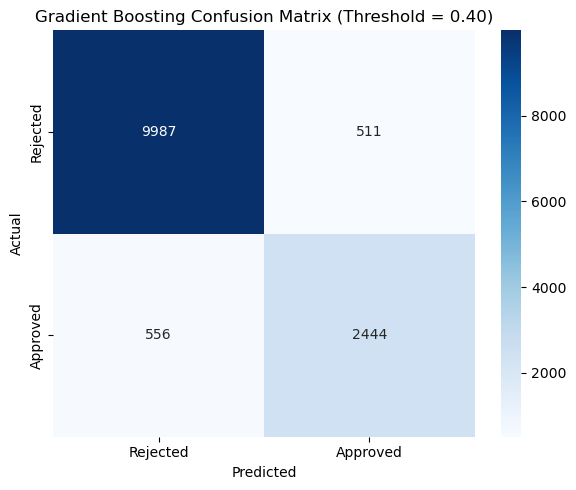

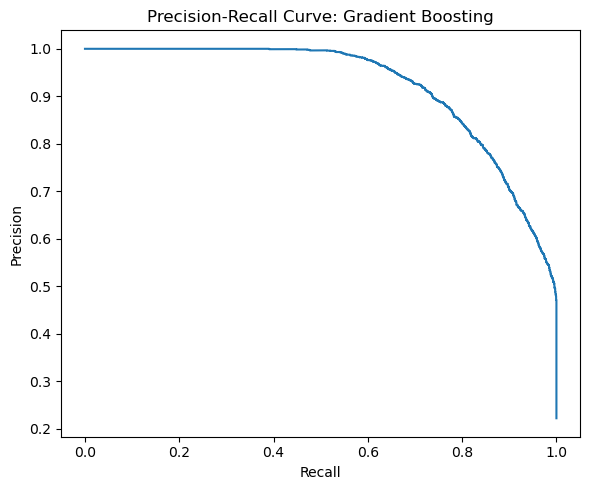

In [17]:
# Classification Threshold Optimization
# Final Model = Gradient Boosting

print_section("CLASSIFICATION THRESHOLD OPTIMIZATION")

threshold_results = find_best_threshold(y_test, gb_prob, metric="f1")
print(threshold_results.head(10))
threshold_results.to_csv(OUTPUT_DIR / "threshold_results_gradient_boosting.csv", index=False)

best_threshold = threshold_results.loc[0, "threshold"]

gb_pred_best_thresh = (gb_prob >= best_threshold).astype(int)
gb_threshold_results = evaluate_classification_model(
    f"Gradient Boosting (threshold={best_threshold:.2f})",
    y_test,
    gb_pred_best_thresh,
    gb_prob,
)
print(pd.DataFrame([gb_threshold_results]))

plot_conf_matrix(
    y_test,
    gb_pred_best_thresh,
    f"Gradient Boosting Confusion Matrix (Threshold = {best_threshold:.2f})",
    "conf_matrix_gb_best_threshold.png",
)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, gb_prob)
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals)
plt.title("Precision-Recall Curve: Gradient Boosting")
plt.xlabel("Recall")
plt.ylabel("Precision")
save_current_plot("precision_recall_curve_gb.png")

INTERPRETABILITY: LOGISTIC REGRESSION
Top positive coefficients:
                          feature  coefficient  abs_coefficient
5             loan_percent_income     1.467470         1.467470
4                   loan_int_rate     0.985291         0.985291
20  loan_intent_DEBTCONSOLIDATION     0.201487         0.201487
19     person_home_ownership_RENT     0.196774         0.196774
1                   person_income     0.171937         0.171937
22    loan_intent_HOMEIMPROVEMENT     0.153093         0.153093
0                      person_age     0.108683         0.108683
17    person_home_ownership_OTHER    -0.000859         0.000859
6      cb_person_cred_hist_length    -0.016385         0.016385
23            loan_intent_MEDICAL    -0.059330         0.059330
2                  person_emp_exp    -0.071428         0.071428
13     person_education_Doctorate    -0.316147         0.316147
12      person_education_Bachelor    -0.410515         0.410515
14   person_education_High School    -0

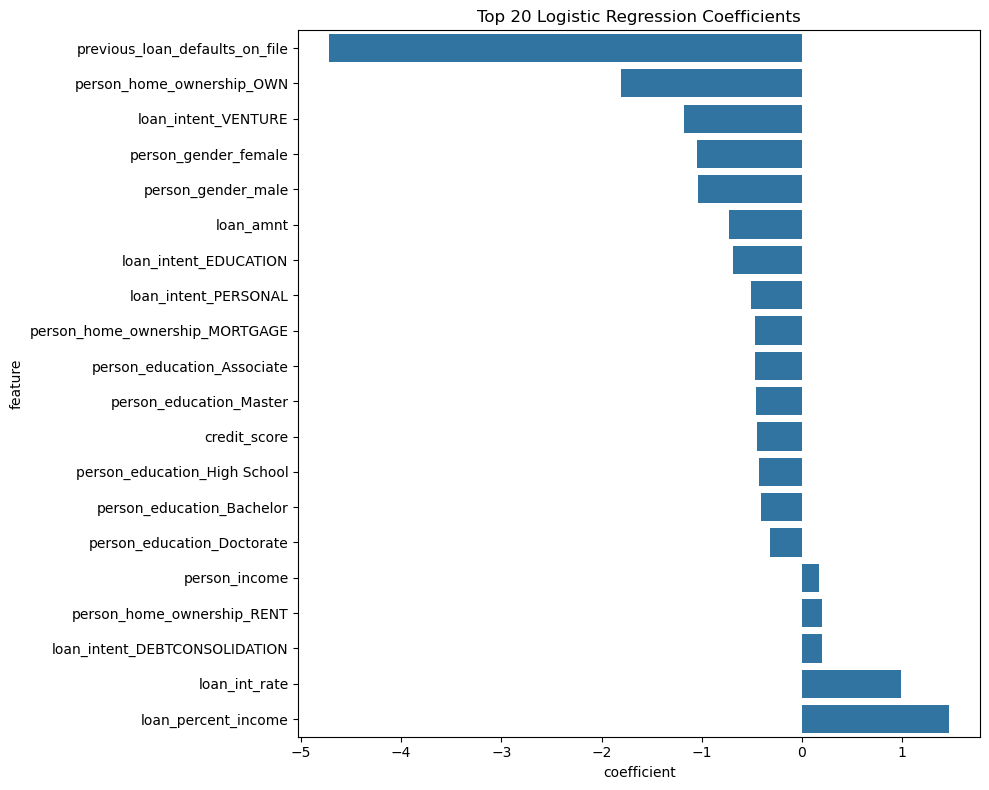

In [18]:
# Logistic Regression Coefficients

print_section("INTERPRETABILITY: LOGISTIC REGRESSION")

fitted_preprocessor = log_reg_pipeline.named_steps["preprocessor"]
feature_names = get_feature_names_from_preprocessor(fitted_preprocessor)
coefficients = log_reg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients),
}).sort_values(by="abs_coefficient", ascending=False)

print("Top positive coefficients:")
print(coef_df.sort_values(by="coefficient", ascending=False).head(15))

print("\nTop negative coefficients:")
print(coef_df.sort_values(by="coefficient", ascending=True).head(15))

coef_df.to_csv(OUTPUT_DIR / "logistic_coefficients.csv", index=False)

plt.figure(figsize=(10, 8))
plot_coef = coef_df.sort_values(by="abs_coefficient", ascending=False).head(20).sort_values(by="coefficient")
sns.barplot(data=plot_coef, x="coefficient", y="feature")
plt.title("Top 20 Logistic Regression Coefficients")
save_current_plot("logistic_top_coefficients.png")

INTERPRETABILITY: RANDOM FOREST
                           feature  importance
8   previous_loan_defaults_on_file    0.340056
4                    loan_int_rate    0.139459
5              loan_percent_income    0.123765
1                    person_income    0.102414
3                        loan_amnt    0.047588
7                     credit_score    0.044795
19      person_home_ownership_RENT    0.031111
0                       person_age    0.026058
2                   person_emp_exp    0.023798
6       cb_person_cred_hist_length    0.021858
16  person_home_ownership_MORTGAGE    0.019845
25             loan_intent_VENTURE    0.009909
18       person_home_ownership_OWN    0.009266
20   loan_intent_DEBTCONSOLIDATION    0.006737
23             loan_intent_MEDICAL    0.006671
22     loan_intent_HOMEIMPROVEMENT    0.006312
21           loan_intent_EDUCATION    0.005752
12       person_education_Bachelor    0.005116
14    person_education_High School    0.004947
11      person_education_Ass

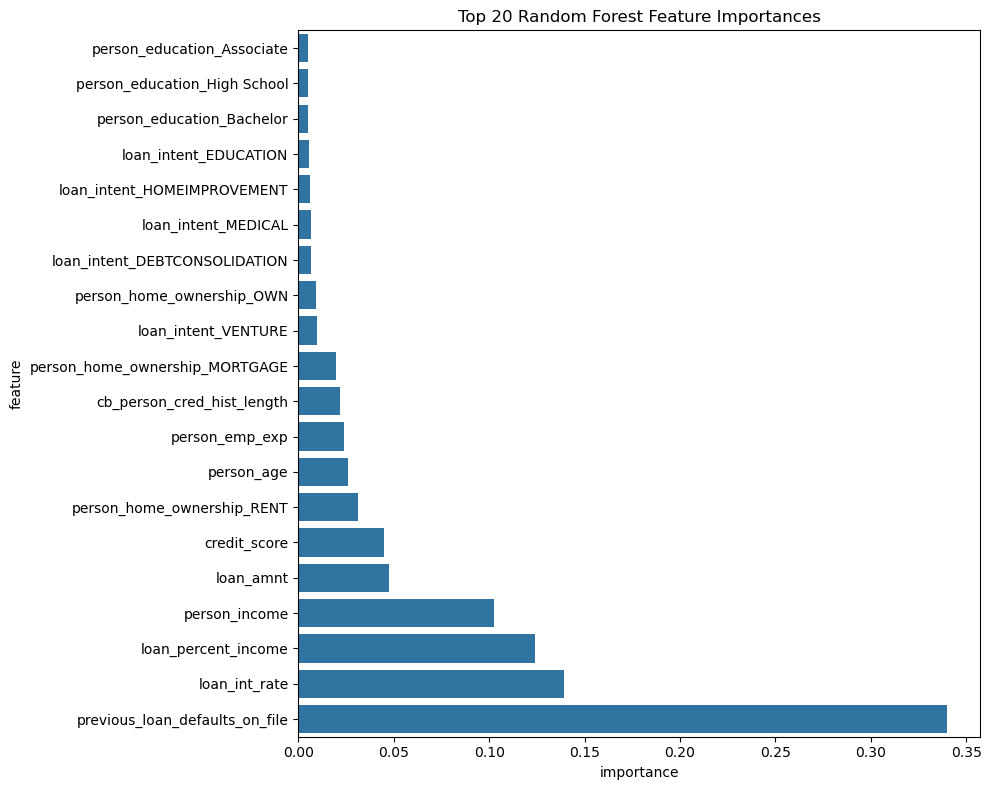

In [19]:
# Random Forest Feature Importance

print_section("INTERPRETABILITY: RANDOM FOREST")

rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_feature_names = get_feature_names_from_preprocessor(rf_preprocessor)
rf_importances = rf_pipeline.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances,
}).sort_values(by="importance", ascending=False)

print(rf_importance_df.head(20))
rf_importance_df.to_csv(OUTPUT_DIR / "random_forest_feature_importance.csv", index=False)

plt.figure(figsize=(10, 8))
plot_imp = rf_importance_df.head(20).sort_values(by="importance")
sns.barplot(data=plot_imp, x="importance", y="feature")
plt.title("Top 20 Random Forest Feature Importances")
save_current_plot("random_forest_feature_importance.png")

INTERPRETABILITY: GRADIENT BOOSTING
                           feature  importance
8   previous_loan_defaults_on_file      0.4526
5              loan_percent_income      0.1800
4                    loan_int_rate      0.1673
1                    person_income      0.0938
19      person_home_ownership_RENT      0.0595
7                     credit_score      0.0124
18       person_home_ownership_OWN      0.0093
20   loan_intent_DEBTCONSOLIDATION      0.0062
22     loan_intent_HOMEIMPROVEMENT      0.0054
25             loan_intent_VENTURE      0.0046
23             loan_intent_MEDICAL      0.0031
0                       person_age      0.0028
21           loan_intent_EDUCATION      0.0018
3                        loan_amnt      0.0006
6       cb_person_cred_hist_length      0.0002
17     person_home_ownership_OTHER      0.0002
16  person_home_ownership_MORTGAGE      0.0001
2                   person_emp_exp      0.0000
12       person_education_Bachelor      0.0000
11      person_education

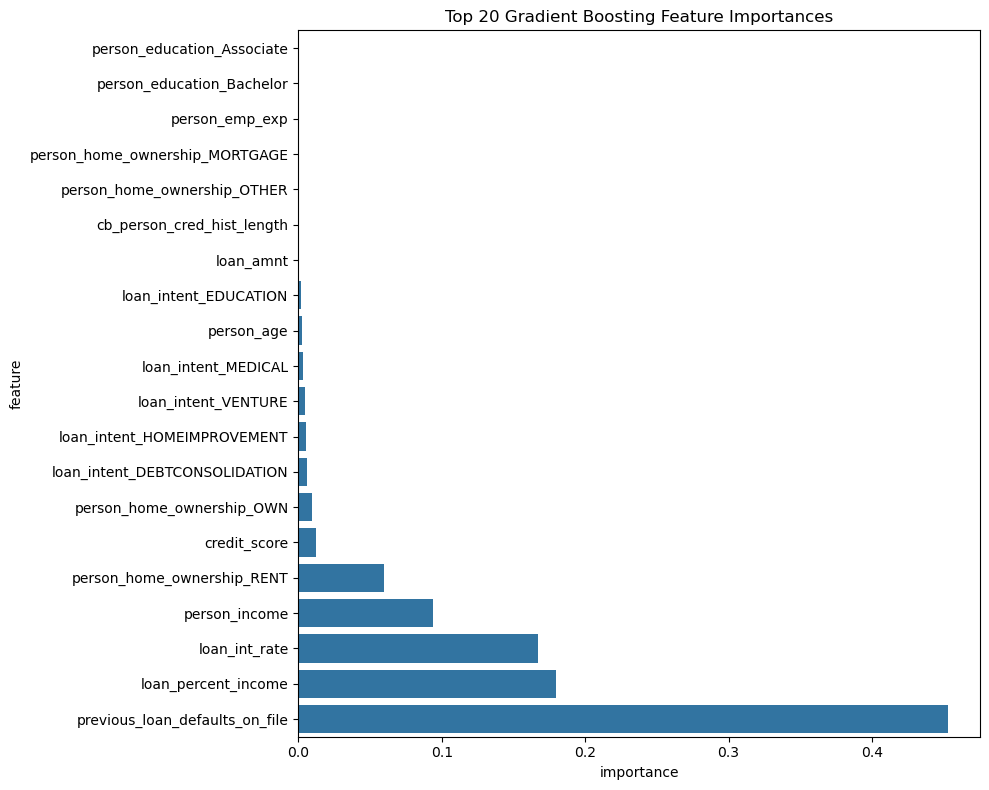

In [20]:
# Gradient Boosting Feature Importance

print_section("INTERPRETABILITY: GRADIENT BOOSTING")

gb_preprocessor = gb_pipeline.named_steps["preprocessor"]
gb_feature_names = get_feature_names_from_preprocessor(gb_preprocessor)
gb_importances = gb_pipeline.named_steps["model"].feature_importances_

gb_importance_df = pd.DataFrame({
    "feature": gb_feature_names,
    "importance": gb_importances,
}).sort_values(by="importance", ascending=False)

print(gb_importance_df.head(20).round(4))
gb_importance_df.to_csv(OUTPUT_DIR / "gradient_boosting_feature_importance.csv", index=False)

plt.figure(figsize=(10, 8))
plot_imp = gb_importance_df.head(20).sort_values(by="importance")
sns.barplot(data=plot_imp, x="importance", y="feature")
plt.title("Top 20 Gradient Boosting Feature Importances")
save_current_plot("gradient_boosting_feature_importance.png")